In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.mast import Observations

# SN2020fqv, cone search around NGC4568 coords instead
obs_table = Observations.query_criteria(
    s_ra=[188.5, 189.5],
    s_dec=[10.8, 11.6],
    obs_collection="HST",
    instrument_name="STIS*"
)

# filter out darks, flats, mirror images
uv_gratings = ["G140L", "G140M", "G230L", "G230M", "G230LB", "G750L", "G750M"]
sci_mask = (
    np.isin(obs_table["filters"], uv_gratings) &
    np.isin(obs_table["target_name"], ["TESS-SN", "SN2020FQV", "AT2020FQV"])
)
sci_obs = obs_table[sci_mask]
print(f"{len(sci_obs)} science spectral observations")
sci_obs["obs_id", "instrument_name", "filters", "t_exptime", "target_name"]


16 science spectral observations


obs_id,instrument_name,filters,t_exptime,target_name
str32,str13,str11,float64,str17
oe2bc1010,STIS/CCD,G230LB,920.0,TESS-SN
oe2bb2010,STIS/CCD,G230LB,920.0,TESS-SN
oe2b02010,STIS/CCD,G230LB,2041.0,TESS-SN
oe2ba2010,STIS/CCD,G230LB,2128.0,TESS-SN
oe2bb3010,STIS/CCD,G230LB,920.0,TESS-SN
oe2ba1010,STIS/CCD,G230LB,2128.0,TESS-SN
oe2bb1010,STIS/CCD,G230LB,2128.0,TESS-SN
oe2b03010,STIS/CCD,G230LB,2041.0,TESS-SN
oe2b01010,STIS/CCD,G230LB,2041.0,TESS-SN


5 x1d files available — downloading first one


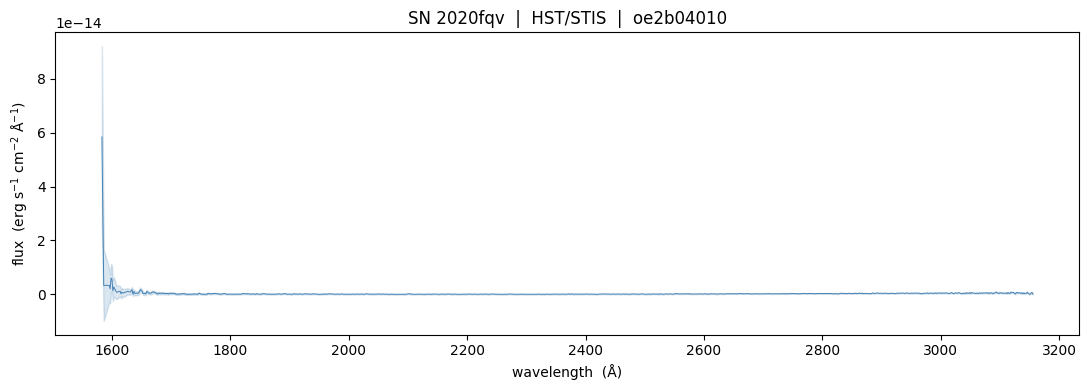

In [ ]:
# pull products from the filtered sci_obs table, grab x1d files
products = Observations.get_product_list(sci_obs)
x1d = Observations.filter_products(products, productSubGroupDescription="X1D", extension="fits")
print(f"{len(x1d)} x1d files available — downloading first one")

manifest = Observations.download_products(x1d[:1], download_dir="./data")
fpath = manifest["Local Path"][0]

with fits.open(fpath) as hdul:
    spec   = hdul[1].data
    wvl    = spec["WAVELENGTH"][0]
    flux   = spec["FLUX"][0]
    err    = spec["ERROR"][0]
    hdr    = hdul[0].header
    obs_id = hdr.get("ROOTNAME", "unknown")

# drop bad pixels, negatives and NaNs from pipeline
mask = np.isfinite(flux) & np.isfinite(err) & (flux > 0) & (err > 0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wvl[mask], flux[mask], lw=0.7, color="steelblue")
ax.fill_between(wvl[mask], flux[mask] - err[mask], flux[mask] + err[mask],
                alpha=0.2, color="steelblue")
ax.set_xlabel("wavelength  (Å)")
ax.set_ylabel("flux  (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
ax.set_title(f"SN 2020fqv  |  HST/STIS  |  {obs_id}")
plt.tight_layout()
plt.show()


---
## SN2024iss STIS test

Shoulda done this bfor: SN2024iss, pull the 2D + default x1d, then run our own ocrreject + x1d trace instead of trusting the pipeline.


In [2]:
# MAST logs SNe under whatever name the proposer typed, so query_criteria(target_name=...) misses.
# objectname runs the name resolver (simbad/ned) -> coords, then cone searches. no manual coords needed.
for nm in ["SN2024iss", "SN 2024iss", "AT2024iss", "2024iss"]:
    try:
        t = Observations.query_criteria(objectname=nm, obs_collection="HST",
                                         instrument_name="STIS*", radius="0.05 deg")
        print(f"{nm:12s} -> {len(t)} STIS obs")
        if len(t):
            iss = t
            break
    except Exception as e:
        print(f"{nm:12s} -> resolver failed ({e})")

iss["obs_id", "instrument_name", "filters", "t_exptime", "target_name", "proposal_id"]


SN2024iss    -> 8 STIS obs


obs_id,instrument_name,filters,t_exptime,target_name,proposal_id
str34,str8,str18,float64,str10,str5
of8b02010,STIS/CCD,G230LB,1923.0,SN2024ISS,17507
hst_hasp_17507_stis_sn2024iss_of8b,STIS,G230LB;G430L;G750L,5905.0,SN2024ISS,17507
of8b02hfq,STIS/CCD,MIRVIS,4.1,SN2024ISS,17507
of8b02030,STIS/CCD,G430L,1065.0,SN2024ISS,17507
of8b02haq,STIS/CCD,MIRVIS,4.1,SN2024ISS,17507
hst_hsla_sn2024iss--6540,STIS,G230LB;G430L;G750L,5905.0,SN 2024iss,17507
of8b02020,STIS/CCD,G230LB,1857.0,SN2024ISS,17507
of8b02040,STIS/CCD,G750L,1060.0,SN2024ISS,17507


In [ ]:
# grab the G230LB exposure (of8b02010, same one the reference uses).
# CCD CRSPLIT data so the pipeline 1d product is SX1 (from the CR-rejected CRJ), not X1D like the mama data.
# flt = flat-fielded 2d subexposures for our own ocrreject. crj/sx1 = pipeline default to compare against.
sci = iss[iss["obs_id"] == "of8b02010"]
prod = Observations.get_product_list(sci)
want = Observations.filter_products(prod, productSubGroupDescription=["FLT", "CRJ", "SX1"], extension="fits")
man = Observations.download_products(want, download_dir="./Data/2024iss")
man["Local Path", "Status"]


INFO: Found cached file ./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_flt.fits with expected size 31567680. [astroquery.query]


Local Path,Status
str60,str8
./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_crj.fits,COMPLETE
./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_flt.fits,COMPLETE
./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_sx1.fits,COMPLETE


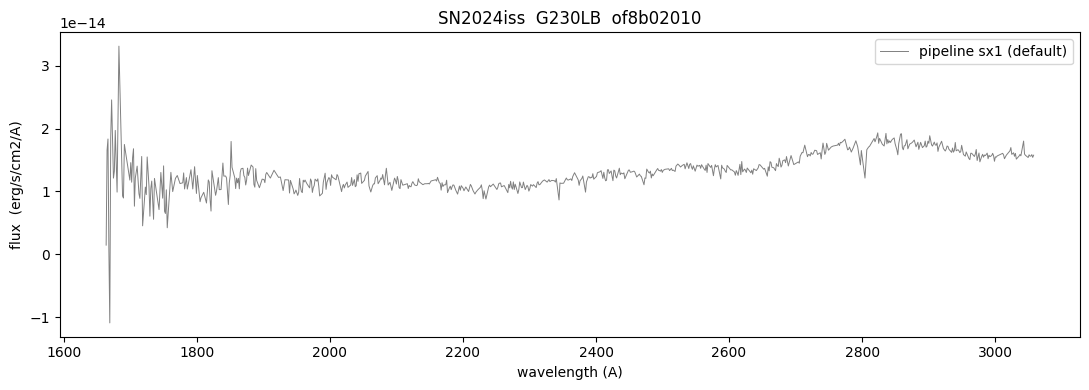

In [2]:
from astropy.table import Table

obsdir   = "./Data/2024iss/mastDownload/HST/of8b02010"
flt      = f"{obsdir}/of8b02010_flt.fits"
crj_pipe = f"{obsdir}/of8b02010_crj.fits"
sx1_pipe = f"{obsdir}/of8b02010_sx1.fits"

# pipeline default 1d extraction (sx1) (what MAST hands us)
sx1 = Table.read(sx1_pipe, hdu=1)
wvl, flx, err, dq = sx1['WAVELENGTH'][0], sx1['FLUX'][0], sx1['ERROR'][0], sx1['DQ'][0]
good = (dq & 16 != 16) & (dq & 512 != 512)

plt.figure(figsize=(11, 4))
plt.plot(wvl[good], flx[good], lw=0.7, color='0.5', label='pipeline sx1 (default)')
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2024iss  G230LB  of8b02010'); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
import os, glob

# stis reduction tools need the crds reference files, resolved through the oref env var.
os.environ['CRDS_SERVER_URL'] = 'https://hst-crds.stsci.edu' # calibration data files
os.environ['CRDS_PATH'] = os.path.abspath('./crds_cache')

# crds on a fresh windows cache errors out writing files before it makes these dirs, so make them first
for sub in ('mappings/hst', 'references/hst', 'config/hst'):
    os.makedirs(f"{os.environ['CRDS_PATH']}/{sub}", exist_ok=True)

import crds # NOTE: SETTING UP CRDS empirically
# downloads the bestref files for these into the cache and stamps the headers with oref$...
crds.assign_bestrefs([flt, crj_pipe], sync_references=True)

# find where crds stashed the stis refs and point oref there so stistools can resolve oref$...
hits = [f for f in glob.glob(os.environ['CRDS_PATH'] + '/references/hst/**', recursive=True) if f.endswith('.fits')]
oref_dir = os.path.dirname(hits[0]) + os.sep
os.environ['oref'] = oref_dir
print(len(hits), "ref files in", oref_dir)


21 ref files in c:\Users\eluru\CALTECH_SURF_2026\WORK\crds_cache/references/hst\stis\


In [10]:
import shutil, stistools.ocrreject, stistools.x1d

crj_ours = f"{obsdir}/230_crj_ours.fits"
x1d_ours = f"{obsdir}/230_x1d_ours.fits"

# stistools is just a wrapper around the compiled hstcal binaries (cs2.e=ocrreject, cs6.e=x1d).
# those dont exist on native windows (hstcal is conda/linux only), so check before calling.
have_hstcal = shutil.which("cs2.e") is not None
print("hstcal available:", have_hstcal)

if have_hstcal:
    for f in (crj_ours, x1d_ours):
        if os.path.exists(f):
            os.remove(f)
    stistools.ocrreject.ocrreject(flt, crj_ours, verbose=False)   # our own CR reject -> our crj
    stistools.x1d.x1d(crj_ours, output=x1d_ours, verbose=False)   # our own 1d extraction
    print("done")
else:
    print("skipping our ocrreject/x1d - needs hstcal binaries (see data_access.md). using pipeline crj/sx1 for the viz below.")


hstcal available: False
skipping our ocrreject/x1d - needs hstcal binaries (see data_access.md). using pipeline crj/sx1 for the viz below.


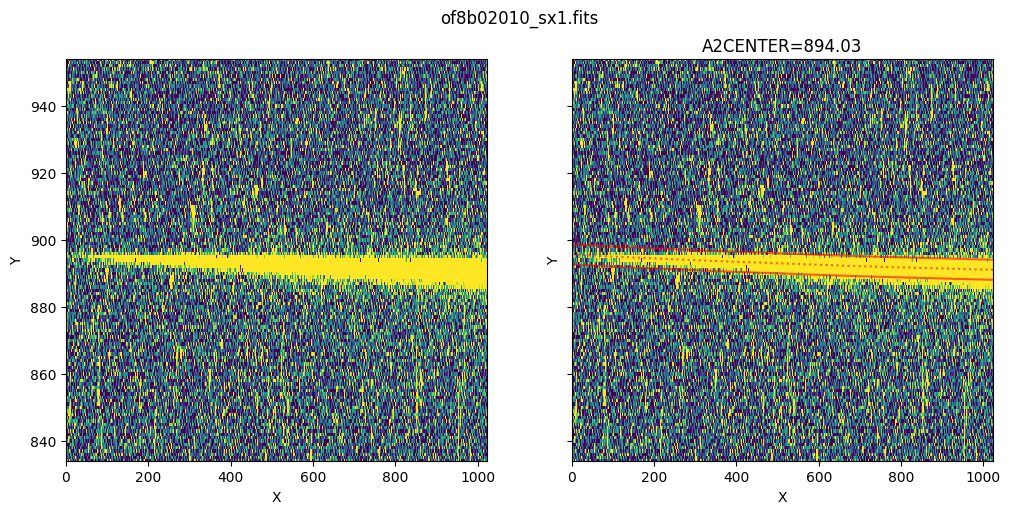

In [3]:
# 2d trace + extraction regions (same helper as the reference notebook).
# red = extraction aperture down the trace, orange = the two bg regions.
def show_extraction_regions(x1d_filename, flt_filename, sci_ext=1, row=0, xrange=None, yrange=None):
    fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
    fig.tight_layout(); fig.subplots_adjust(wspace=0.2, top=0.88)
    fig.suptitle(os.path.basename(x1d_filename))

    x1d = fits.getdata(x1d_filename, ext=sci_ext)[row]
    flt = fits.getdata(flt_filename, ext=('SCI', sci_ext))

    for ax in axes:
        ax.imshow(flt, origin='lower', interpolation='none', aspect='auto', vmin=-6, vmax=15)
        ax.set_xlabel('X'); ax.set_ylabel('Y')

    axes[1].set_title(f"A2CENTER={x1d['A2CENTER']:.2f}")
    # extraction region (red)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1, 'r:', alpha=0.6)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 - x1d['EXTRSIZE'] // 2, color='red', alpha=0.6)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['EXTRSIZE'] // 2, color='red', alpha=0.6)
    # bg regions (orange)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK1OFFST'] - x1d['BK1SIZE'] // 2, color='orange', alpha=0.6)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK1OFFST'] + x1d['BK1SIZE'] // 2, color='orange', alpha=0.6) # adjust this
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK2OFFST'] - x1d['BK2SIZE'] // 2, color='orange', alpha=0.6) # adjust this
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK2OFFST'] + x1d['BK2SIZE'] // 2, color='orange', alpha=0.6)

    for ax in axes:
        ax.set_xlim(-0.5, 1023.5); ax.set_ylim(-0.5, 1023.5)
    if xrange: axes[0].set_xlim(*xrange); axes[1].set_xlim(*xrange)
    if yrange: axes[0].set_ylim(*yrange); axes[1].set_ylim(*yrange)
    # constrain y to 870-910 and review aperture

from astropy.io import fits
a2 = fits.getdata(sx1_pipe, ext=1)[0]['A2CENTER']
show_extraction_regions(sx1_pipe, flt, yrange=[a2 - 60, a2 + 60])
plt.show()


### our own extraction (ran in WSL)

turns out hstcal binaries dont run on native windows, so the actual ocrreject + x1d ran in WSL (Debian, `surf_uv` conda env) via `reduce_stis.py`. it reused the crds refs we synced above and wrote `230_crj_ours.fits` / `230_x1d_ours.fits` back into the same folder. now read our x1d back and compare to the pipeline sx1.


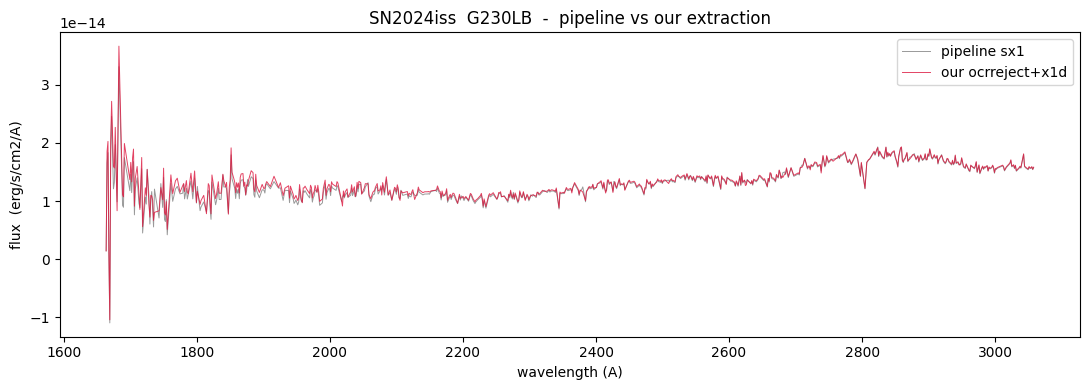

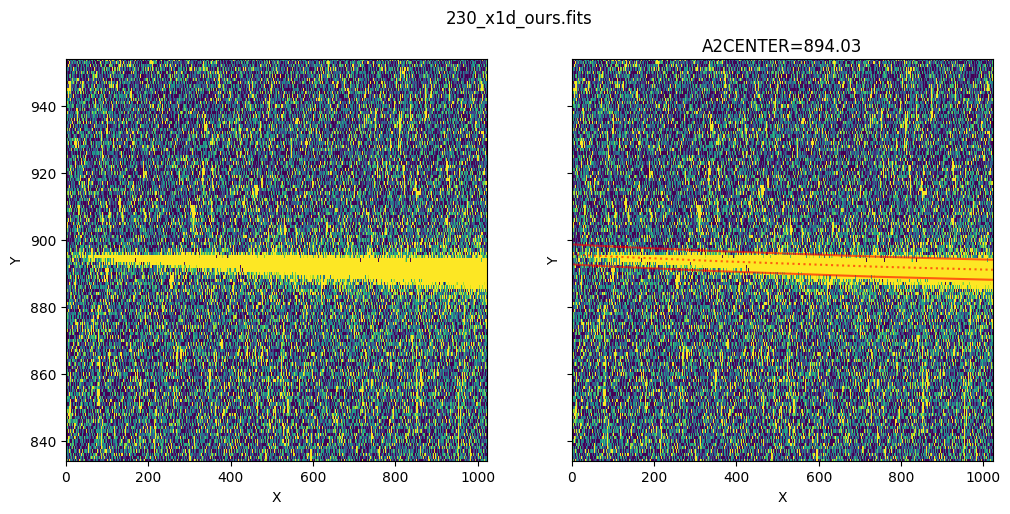

In [12]:
# read our wsl-made x1d and overplot on the pipeline sx1
ours = Table.read(x1d_ours, hdu=1)
w_o, f_o, dq_o = ours['WAVELENGTH'][0], ours['FLUX'][0], ours['DQ'][0]
g_o = (dq_o & 16 != 16) & (dq_o & 512 != 512)

plt.figure(figsize=(11, 4))
plt.plot(wvl[good], flx[good], lw=0.7, color='0.6', label='pipeline sx1')
plt.plot(w_o[g_o], f_o[g_o], lw=0.7, color='crimson', alpha=0.8, label='our ocrreject+x1d')
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2024iss  G230LB  -  pipeline vs our extraction'); plt.legend()
plt.tight_layout(); plt.show()

# our extraction regions on the 2d
a2o = ours[0]['A2CENTER']
show_extraction_regions(x1d_ours, flt, yrange=[a2o - 60, a2o + 60])
plt.show()


### playing with the extraction: close background regions

cells above kept everything default. the default bg sits at offset -300/-320 (both ~300px below the trace, near the top detector edge), so the orange lines were way off-screen. here we re-extract with bg straddling the trace (a2center=894, extrsize=5, bk1offst=-14, bk2offst=+14, sizes 10, maxsrch=0). that puts the bottom bg region lines near y=875 and 885, top region near 903/913. ran in WSL via `reduce_stis.py`. now the orange shows next to the red aperture, and we can see if the tighter sky region changes the spectrum.


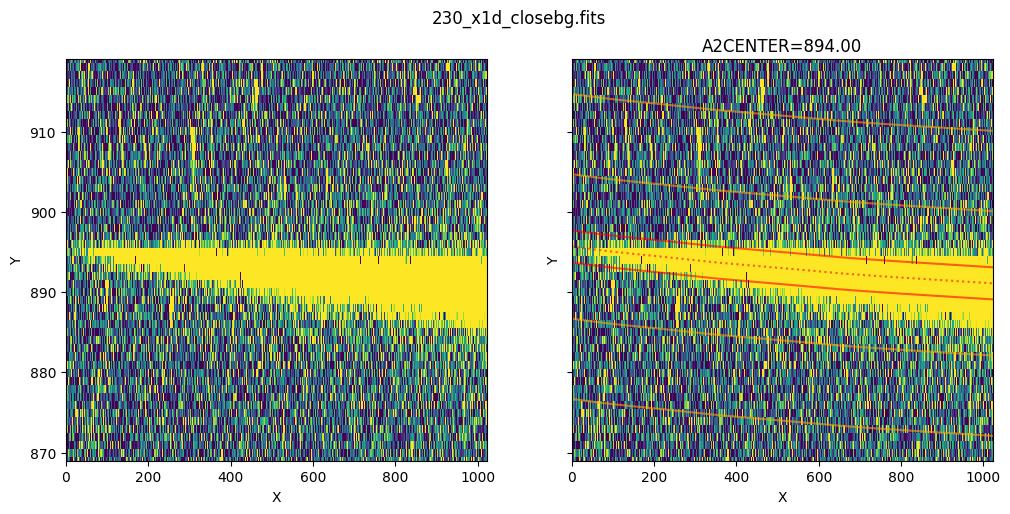

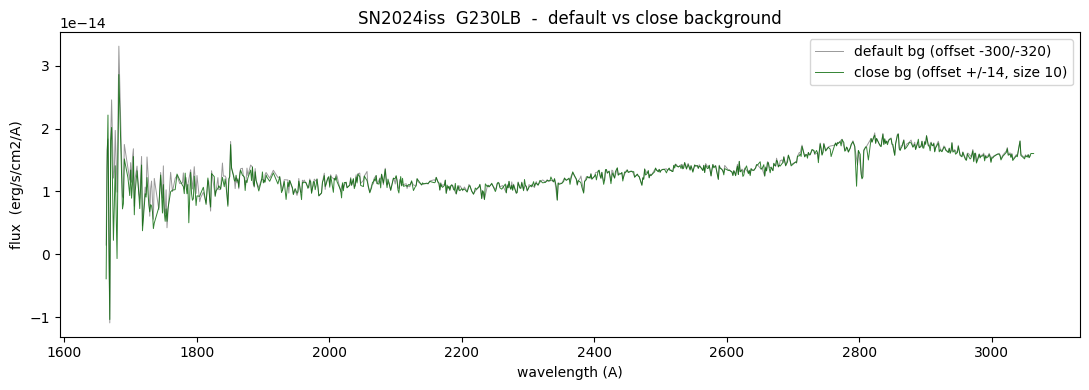

In [5]:
# close-bg extraction we just made in wsl. now the bg regions straddle the trace
x1d_close = f"{obsdir}/230_x1d_closebg.fits"
close = Table.read(x1d_close, hdu=1)
a2c = close[0]['A2CENTER']

# tight zoom so we can actually see the aperture (red) + the two close bg regions (orange)
show_extraction_regions(x1d_close, flt, yrange=[a2c - 25, a2c + 25])
plt.show()

# does the tighter sky region change the spectrum? default bg vs close bg
wc, fc, dqc = close['WAVELENGTH'][0], close['FLUX'][0], close['DQ'][0]
gc = (dqc & 16 != 16) & (dqc & 512 != 512)

plt.figure(figsize=(11, 4))
plt.plot(wvl[good], flx[good], lw=0.7, color='0.6', label='default bg (offset -300/-320)')
plt.plot(wc[gc], fc[gc], lw=0.7, color='darkgreen', alpha=0.8, label='close bg (offset +/-14, size 10)')
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2024iss  G230LB  -  default vs close background'); plt.legend()
plt.tight_layout(); plt.show()


### extraction param sweeps

now actually vary the knobs (all run in WSL via `reduce_stis_sweep.py`, bg fixed at +/-14). first `extrsize` (aperture height) for the flux vs noise tradeoff, then deliberately miscenter the aperture to see flux loss.


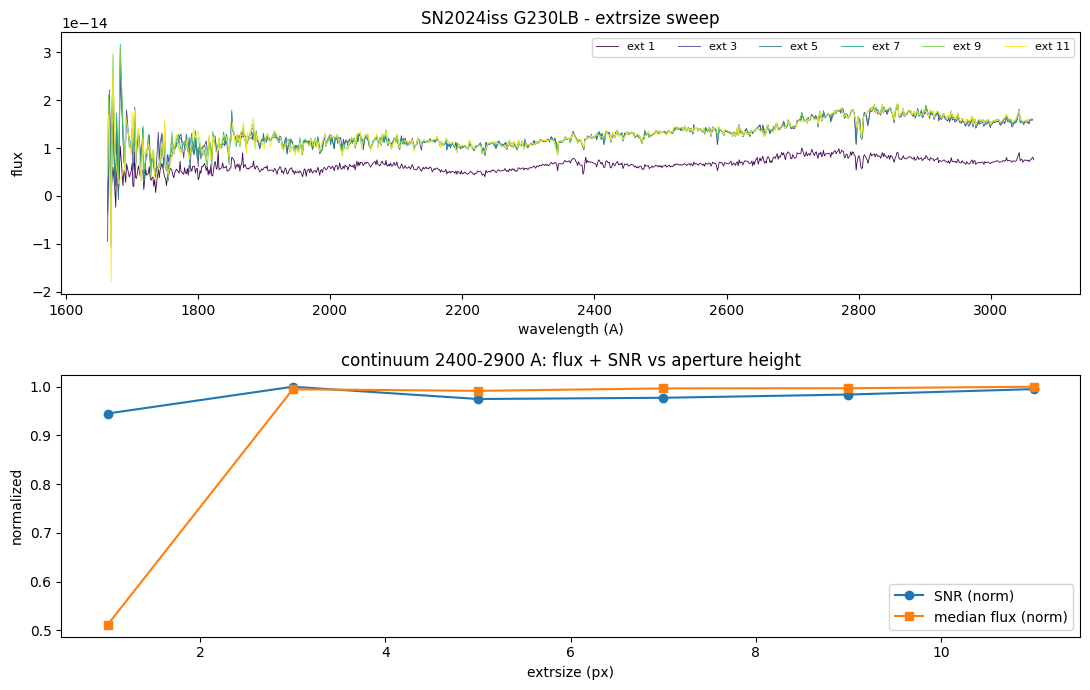

In [6]:
# extrsize sweep: aperture height trades flux vs noise. pipeline default for this mode was 7
exts = [1, 3, 5, 7, 9, 11]
win = (2400, 2900)   # clean-ish continuum window for a quick snr proxy
cols = plt.cm.viridis(np.linspace(0, 1, len(exts)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))
snrs, fluxes = [], []
for e, c in zip(exts, cols):
    t = Table.read(f"{obsdir}/230_x1d_ext{e}.fits", hdu=1)
    w, f, dq = t['WAVELENGTH'][0], t['FLUX'][0], t['DQ'][0]
    g = (dq & 16 != 16) & (dq & 512 != 512)
    ax1.plot(w[g], f[g], lw=0.6, color=c, label=f'ext {e}')
    sel = np.asarray(f[g & (w > win[0]) & (w < win[1])], float)
    snrs.append(np.median(sel) / np.std(sel))
    fluxes.append(np.median(sel))
ax1.set_xlabel('wavelength (A)'); ax1.set_ylabel('flux'); ax1.legend(ncol=6, fontsize=8)
ax1.set_title('SN2024iss G230LB - extrsize sweep')

ax2.plot(exts, np.array(snrs) / max(snrs), 'o-', label='SNR (norm)')
ax2.plot(exts, np.array(fluxes) / max(fluxes), 's-', label='median flux (norm)')
ax2.set_xlabel('extrsize (px)'); ax2.set_ylabel('normalized'); ax2.legend()
ax2.set_title(f'continuum {win[0]}-{win[1]} A: flux + SNR vs aperture height')
plt.tight_layout(); plt.show()


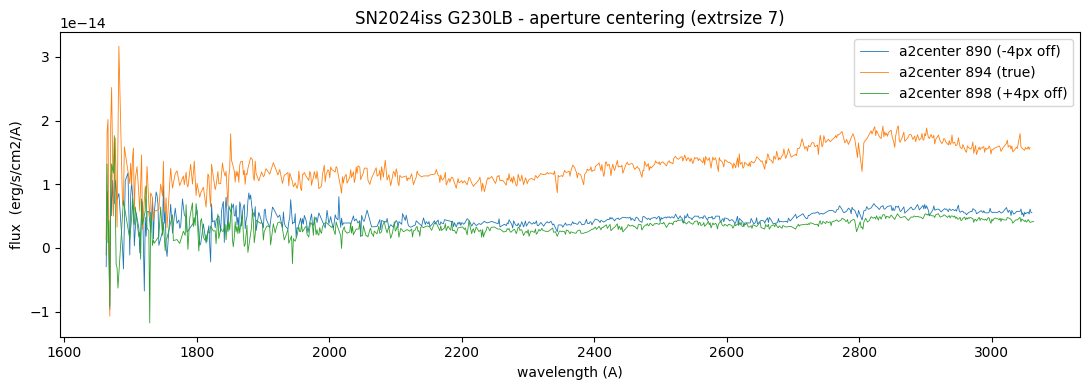

In [7]:
# miscentering: force a2center off the true trace (~894) with maxsrch=0, extrsize fixed at 7
plt.figure(figsize=(11, 4))
for cc in [890, 894, 898]:
    t = Table.read(f"{obsdir}/230_x1d_cen{cc}.fits", hdu=1)
    w, f, dq = t['WAVELENGTH'][0], t['FLUX'][0], t['DQ'][0]
    g = (dq & 16 != 16) & (dq & 512 != 512)
    lbl = f'a2center {cc}' + (' (true)' if cc == 894 else f' ({cc - 894:+d}px off)')
    plt.plot(w[g], f[g], lw=0.6, label=lbl)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2024iss G230LB - aperture centering (extrsize 7)'); plt.legend()
plt.tight_layout(); plt.show()


---
## STIS coadd: stitch the gratings into one spectrum

SN2024iss was observed in G230LB (NUV/blue), G430L (optical), G750L (red). to get one full spectrum we resample each onto a common wavelength axis (specutils FluxConservingResampler, native dispersions from the PI's combine_spectra_reference) then median-combine. overlaps get the median of the contributing gratings, elsewhere the single grating. using our own G230LB extraction + the pipeline G430L/G750L (any input can be swapped for a custom extraction).


        Use Spectrum instead. [_py_warnings]
        Use Spectrum instead. [_py_warnings]
        Use Spectrum instead. [_py_warnings]
C:\Users\eluru\AppData\Local\Temp\ipykernel_35832\442291858.py:29: RuntimeWarning: All-NaN slice encountered
  coadd = np.nanmedian(stack, axis=0)


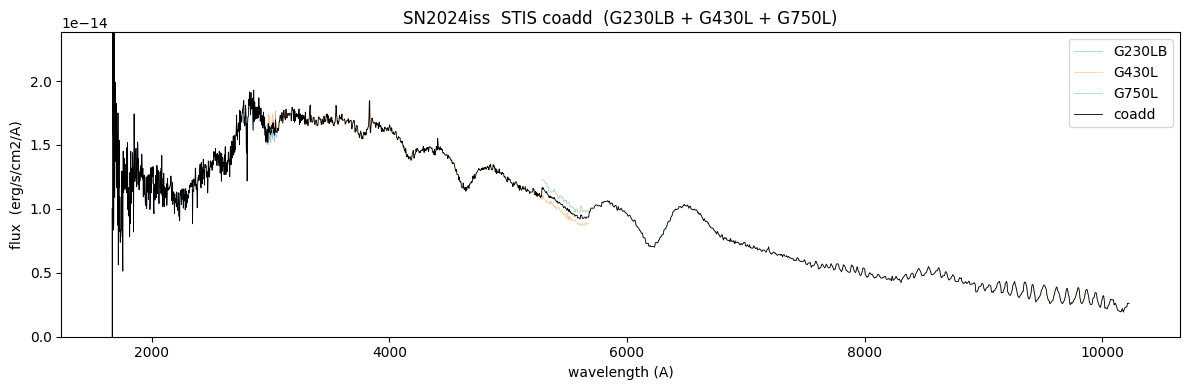

In [8]:
import astropy.units as u
from specutils.manipulation import FluxConservingResampler
try:
    from specutils import Spectrum1D
except ImportError:
    from specutils import Spectrum as Spectrum1D

specs = {
    'G230LB': f"{obsdir}/230_x1d_ours.fits",  # our own extraction
    'G430L':  "./Data/2024iss/mastDownload/HST/of8b02030/of8b02030_sx1.fits",
    'G750L':  "./Data/2024iss/mastDownload/HST/of8b02040/of8b02040_sx1.fits",
}
# common axis at each grating's native dispersion (from the PI's reference)
axis = np.concatenate([np.arange(1667, 3040, 1.37), np.arange(3040, 5615, 2.75),
                       np.arange(5615, 10250, 4.87)]) * u.AA
rs = FluxConservingResampler(extrapolation_treatment='nan_fill')
flam = u.erg / u.s / u.cm**2 / u.AA

resamp = {}
for grat, fn in specs.items():
    tb = Table.read(fn, hdu=1)
    wv, fx, dqf = tb['WAVELENGTH'][0], tb['FLUX'][0], tb['DQ'][0]
    ok = (dqf & 16 != 16) & (dqf & 512 != 512) & np.isfinite(fx) & (fx != 0)
    sp = Spectrum1D(spectral_axis=np.asarray(wv[ok], float) * u.AA, flux=np.asarray(fx[ok], float) * flam)
    resamp[grat] = rs(sp, axis)

# median across the gratings: overlaps -> median, elsewhere -> the single grating
stack = np.vstack([r.flux.value for r in resamp.values()])
coadd = np.nanmedian(stack, axis=0)

plt.figure(figsize=(12, 4))
for grat, r in resamp.items():
    plt.plot(axis, r.flux.value, lw=0.5, alpha=0.45, label=grat)
plt.plot(axis, coadd, lw=0.6, color='k', label='coadd')
lo, hi = np.nanpercentile(coadd, [1, 99])
plt.ylim(lo - abs(lo), hi * 1.3)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)'); plt.legend()
plt.title('SN2024iss  STIS coadd  (G230LB + G430L + G750L)')
plt.tight_layout(); plt.show()
